In [ ]:
# Import dependencies
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from pathlib import Path
import pandas as pd

# Import the data
drive.mount('/content/drive')
folder_path= '/content/drive/My Drive/RNN_Final'
directory = Path(folder_path)

index = directory / 'CPIAUCSL.csv'
median = directory / 'h09ar.csv'

# Prepare the data for creating the final dataframe
df_median = pd.read_csv(median, skiprows=1, header=None)
df_median.columns = ['Year', 'Median_Income_UA', 'Median_Income_A', 'Mean_Income_UA', 'Mean_Income_A']
for col in df_median.columns:
    if df_median[col].dtype == 'object':
          df_median[col] = df_median[col].str.replace(',', '', regex=False).astype(int)
          print(f"Converted column '{col}' to integer.")
df_cpi = pd.read_csv(index)
df_cpi['observation_date'] = pd.to_datetime(df_cpi['observation_date'])
df_cpi = df_cpi[df_cpi['observation_date'].dt.year >= 1980]

Mounted at /content/drive
Converted column 'Median_Income_UA' to integer.
Converted column 'Median_Income_A' to integer.
Converted column 'Mean_Income_UA' to integer.
Converted column 'Mean_Income_A' to integer.


In [ ]:
#Messy ahh way to build the dataframe, but it works.

cpi_list = df_cpi.iloc[:, 1].tolist()
cpi_dates_list = df_cpi.iloc[:, 0].tolist()
median_list = df_median.iloc[:, 1].tolist()
median_list.reverse()
median_long = []
ratio_list = []

index = 0
index2 = 0
index3 = 0

max_cpi_index_to_process = len(median_list) * 12

while index < len(cpi_list) and index < max_cpi_index_to_process:
  if index2 == 12:
    index2 = 0
    index3 += 1

  ratio_list.append(cpi_list[index] / median_list[index3])
  median_long.append(median_list[index3])
  index += 1
  index2 += 1
print('Done')

print(len(median_long), len(ratio_list), len(cpi_list))

Done
549 549 549


In [ ]:
#Finally build the dataframe
dates_for_export = cpi_dates_list[:len(ratio_list)]

df_export = pd.DataFrame({
    'Date': dates_for_export,
    'CPI_to_Median_Ratio': ratio_list,
    'Median_Income': median_long,
    'CPI': cpi_list
})

display(df_export.head())

,Date,CPI_to_Median_Ratio,Median_Income,CPI
0,1980-01-01,0.004404,17710,78.0
1,1980-02-01,0.004461,17710,79.0
2,1980-03-01,0.004523,17710,80.1
3,1980-04-01,0.004568,17710,80.9
4,1980-05-01,0.004613,17710,81.7


In [ ]:
#Import more dependencies
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

#Declare the data that will be used for training
vars = ['CPI_to_Median_Ratio', 'Median_Income', 'CPI']
data_for_model = df_export[vars].values
n_vars = data_for_model.shape[1]

#Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_for_model)

target_scaler = MinMaxScaler(feature_range=(0, 1))
target_data_for_scaler = df_export[['CPI_to_Median_Ratio']].values
target_scaler.fit(target_data_for_scaler)

#Prepare the data by converting it to n_steps_in and n_steps_out to predict out using in
def preprocess_sequence_multivariate(data, target_column_index, n_steps_in, n_steps_out):
    X, y = [], []
    for i in range(len(data)):
        end = i + n_steps_in
        out = end + n_steps_out

        if out > len(data):
            break

        seq_x = data[i:end, :]
        seq_y = data[end:out, target_column_index]

        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y).reshape((len(y), n_steps_out, 1))

n_steps_in = 20
target_column_index = vars.index('CPI_to_Median_Ratio')

In [ ]:
#Build the encoder-decoder as stated by the method name
def build_encoder_decoder(n_steps_in, n_steps_out, n_vars):

    #Building the encoder
    inputs = Input(shape=(n_steps_in, n_vars))
    encoder = LSTM(100, activation='tanh')(inputs)
    encoded = RepeatVector(n_steps_out)(encoder)

    #Now the decoder
    decoder = LSTM(100, activation='tanh', return_sequences=True)(encoded)
    outputs = TimeDistributed(Dense(1))(decoder)
    js_model = Model(inputs=inputs, outputs=outputs)

    #Didn't need to tune the learning rate much.
    js_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, clipvalue=1.0), loss='mse')
    return js_model

In [ ]:
#Train the model
n_steps_out_training = 1

#Running the data prep
X, y = preprocess_sequence_multivariate(scaled_data, target_column_index, n_steps_in, n_steps_out_training)

#Running the build_encoder_decoder method.
js_model = build_encoder_decoder(n_steps_in, n_steps_out_training, n_vars)
js_model.summary()

js_history = js_model.fit(X, y, epochs=100, verbose=1)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 100)         │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 1)           │           101 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,101 (476.96 KB)

 Trainable params: 122,101 (476.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2590
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2220
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1508
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0805
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0345
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0194
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0083
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0061
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0066
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0066
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0063
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0066
Epoch 13/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0068
Epoch 14/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0065
Epoch 15/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - lo

In [ ]:
#I had help from Gemini with this code block. I consistently ran into problems where my predictions would be flat or wouldn't make any snese given historical trends.
#It was especially helpful with the iterative forecasting.

#Declare the number of months for forecasting
n_months = 240

#Reshape the data
initial_input_sequence = scaled_data[-n_steps_in:].reshape(1, n_steps_in, n_vars)

#This is all getting ready to a creating the future data for the iterative forecasting
num_hist = min(12, len(data_for_model))
last_vals = data_for_model[-num_hist:]
monthly_rates = np.zeros(n_vars)

#This is and below are the Gemini code
#This loop fills monthly growth rates
for vars_n in range(n_vars):
    if vars_n != target_column_index:
        if last_vals[0, vars_n] != 0:
            growth = (last_vals[-1, vars_n] - last_vals[0, vars_n]) / last_vals[0, vars_n]
            monthly_rates[vars_n] = (1 + growth)**(1/num_hist) - 1
        else:
            monthly_rates[i] = 0


fut_pred_scaled = []
current_input_for_prediction = initial_input_sequence


last_actual_features = df_export[vars].iloc[-1].values
current_future_aux_features_original_scale = last_actual_features.copy()

#Perform iterative forecasting
#This is essentially just running a loop that runs through the inputted number of months and runs .predict()
#It then fills in the new feature and scales it, so it can be used in future predictions. And reshpes the data, so the new data can be used.
for _ in range(n_months):
    predicted_output_for_next_step_scaled = js_model.predict(current_input_for_prediction, verbose=0)[0]

    next_predicted_target_value_scaled = predicted_output_for_next_step_scaled[0, 0]
    fut_pred_scaled.append(next_predicted_target_value_scaled)

    for i in range(n_vars):
        if i != target_column_index:
            current_future_aux_features_original_scale[i] *= (1 + monthly_rates[i])

    new_feature_vector_original_scale = current_future_aux_features_original_scale.copy()
    next_predicted_target_value_original_scale = target_scaler.inverse_transform([[next_predicted_target_value_scaled]])[0,0]

    new_feature_vector_original_scale[target_column_index] = next_predicted_target_value_original_scale
    new_feature_vector_scaled = scaler.transform(new_feature_vector_original_scale.reshape(1, -1))[0]
    current_input_for_prediction = np.append(
        current_input_for_prediction[:, 1:, :],
        new_feature_vector_scaled.reshape(1, 1, n_vars),
        axis=1
    )

future_predictions_original_scale = target_scaler.inverse_transform(np.array(fut_pred_scaled).reshape(-1, 1)).flatten()

original_target_scaled = scaled_data[:, target_column_index]
original_target = target_scaler.inverse_transform(original_target_scaled.reshape(-1, 1)).flatten()
last_date = df_export['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_months, freq='MS')
all_dates = pd.to_datetime(df_export['Date'].tolist() + future_dates.tolist())
combined_values = np.concatenate((original_target, future_predictions_original_scale))

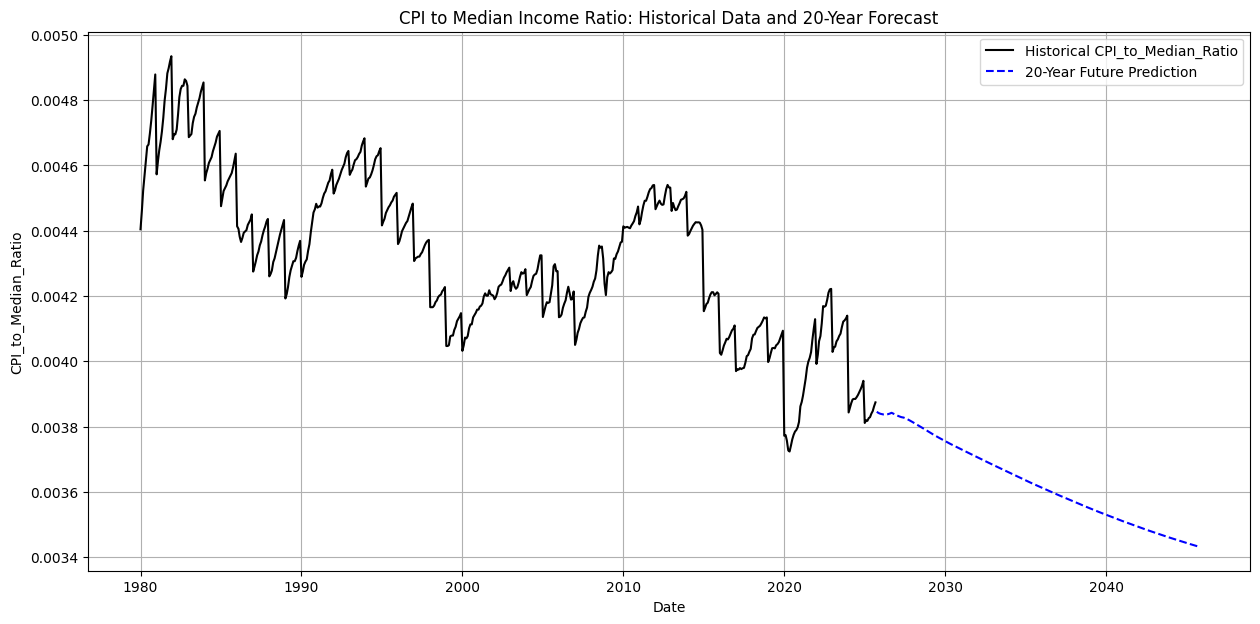


--- 20 Year Forecast ---
The CPI to Median Income Ratio is forecasted to change from approximately 0.0038 at the start of the prediction period to 0.0034 at the end of 20 years.
This represents a decrease of 10.71% over the next two decades.


In [ ]:
# Plot the final results

plt.figure(figsize=(15, 7))
plt.plot(df_export['Date'], original_target, label='Historical CPI_to_Median_Ratio', color='black')
plt.plot(future_dates, future_predictions_original_scale, label='20-Year Future Prediction', color='blue', linestyle='--')

plt.title('CPI to Median Income Ratio: Historical Data and 20-Year Forecast')
plt.xlabel('Date')
plt.ylabel('CPI_to_Median_Ratio')
plt.legend()
plt.grid(True)
plt.show()


print("\n--- 20 Year Forecast ---")
if len(future_predictions_original_scale) > 0:
    start_val = future_predictions_original_scale[0]
    end_val = future_predictions_original_scale[-1]
    change = (end_val - start_val) / start_val * 100
    print(f"The CPI to Median Income Ratio is forecasted to change from approximately {start_val:.4f} at the start of the prediction period to {end_val:.4f} at the end of 20 years.")
    print(f"This represents a {'increase' if change > 0 else 'decrease'} of {abs(change):.2f}% over the next two decades.")

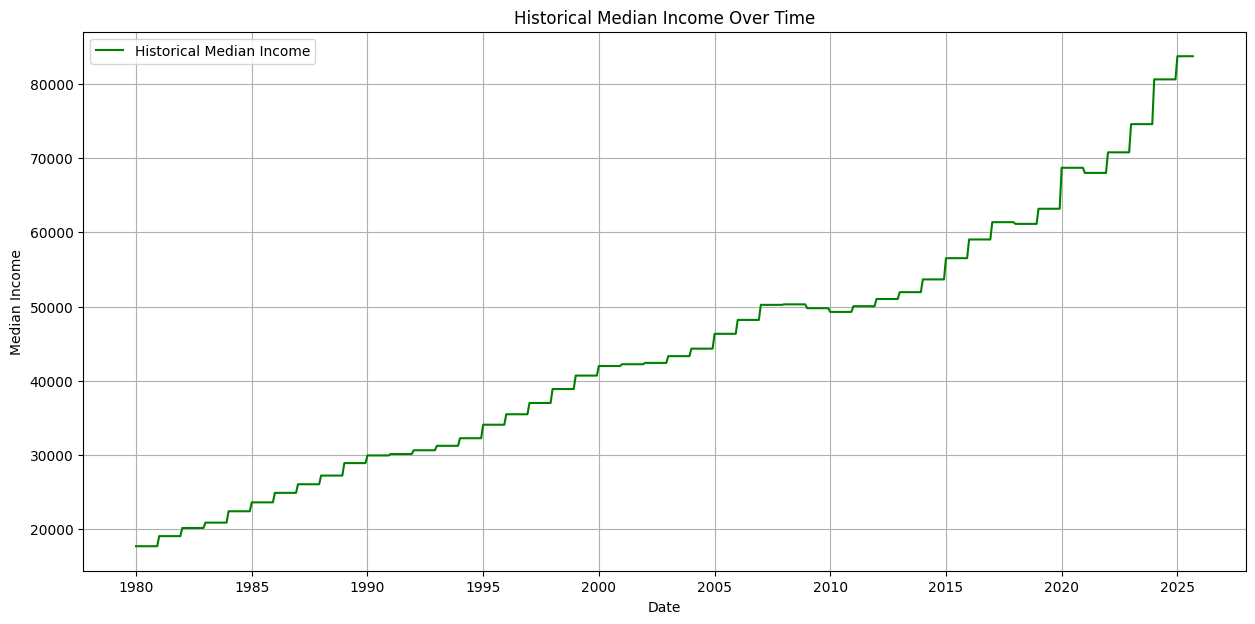

In [ ]:
# Plot the historical median income
plt.figure(figsize=(15, 7))
plt.plot(df_export['Date'], df_export['Median_Income'], label='Historical Median Income', color='green')

plt.title('Historical Median Income Over Time')
plt.xlabel('Date')
plt.ylabel('Median Income')
plt.legend()
plt.grid(True)
plt.show()

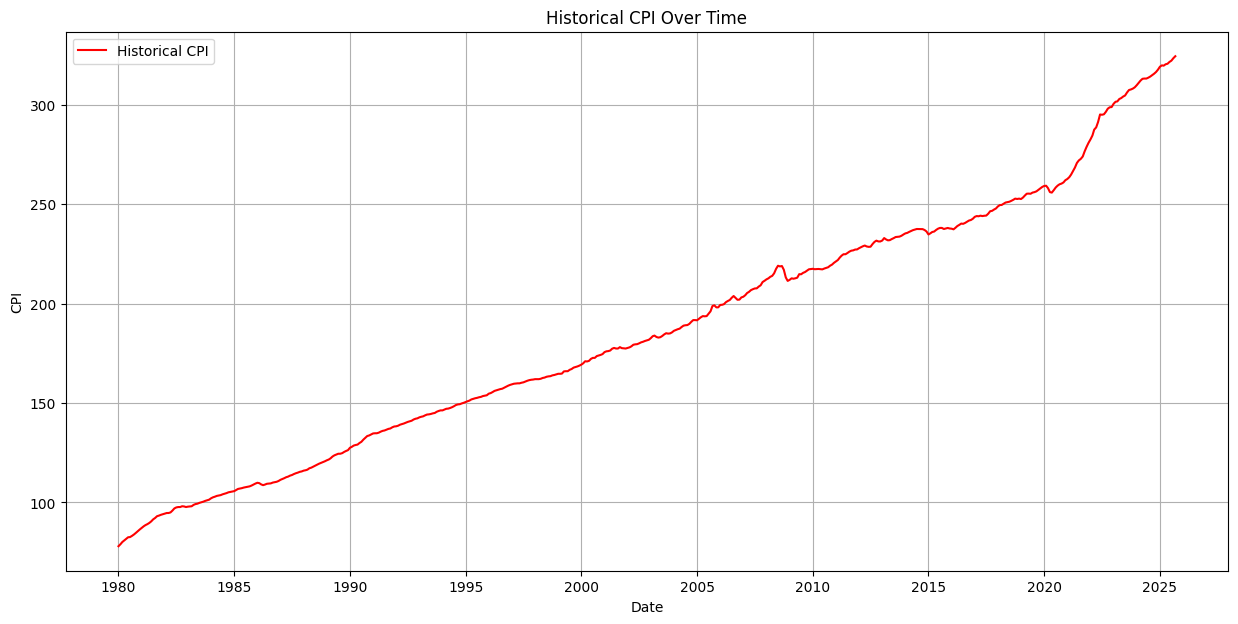

In [ ]:
#Plot the historical CPI
plt.figure(figsize=(15, 7))
plt.plot(df_export['Date'], df_export['CPI'], label='Historical CPI', color='red')

plt.title('Historical CPI Over Time')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.legend()
plt.grid(True)
plt.show()